<a href="https://colab.research.google.com/github/kshupe/wildlife-data-portfolio/blob/main/notebooks/elephantprofile_function.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Set Up Packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys

# Connect to Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Project base path - change this one line if the project ever moves or renames
BASE_PATH = "/content/drive/MyDrive/wildlife_data/projects/elephants_temperature_knp"

# Make src/ importable, then pull in the reusable functions
sys.path.append(f"{BASE_PATH}/src")

from movement_metrics import haversine_m, bearing_deg, add_movement_metrics
from elephant_profiles import elephant_profile, elephant_profile_pdf

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
# Load processed movement data
df_moves = pd.read_parquet(f"{BASE_PATH}/data/processed/df_moves_processed.parquet")
print(df_moves.shape)
df_moves.head()

(283688, 22)


,event-id,visible,timestamp,location-long,location-lat,external-temperature,sensor-type,individual-taxon-canonical-name,tag-local-identifier,individual-local-identifier,...,utm-northing,utm-zone,study-timezone,study-local-timestamp,step_dist_m,step_dt_s,bearing_deg,speed_mps,turn_angle_deg,hour
0,9421351127,True,2007-08-13 00:30:00,31.87091,-24.81373,24.0,gps,Loxodonta africana,AM105,AM105,...,7.255206e+06,36S,GMT+02:00,2007-08-13 02:30:00.000,NaN,NaN,NaN,NaN,NaN,0
1,9421351128,True,2007-08-13 02:00:00,31.87399,-24.81483,23.0,gps,Loxodonta africana,AM105,AM105,...,7.255086e+06,36S,GMT+02:00,2007-08-13 04:00:00.000,334.058161,5400.0,111.478839,0.061863,NaN,2
2,9421351129,True,2007-08-13 03:31:00,31.87724,-24.81673,21.0,gps,Loxodonta africana,AM105,AM105,...,7.254879e+06,36S,GMT+02:00,2007-08-13 05:31:00.000,390.164560,5460.0,122.785836,0.071459,11.306997,3
3,9421351130,True,2007-08-13 04:00:00,31.87822,-24.81569,21.0,gps,Loxodonta africana,AM105,AM105,...,7.254995e+06,36S,GMT+02:00,2007-08-13 06:00:00.000,152.171393,1740.0,40.540373,0.087455,-82.245463,4
4,9421351131,True,2007-08-13 06:00:00,31.89554,-24.79870,22.0,gps,Loxodonta africana,AM105,AM105,...,7.256890e+06,36S,GMT+02:00,2007-08-13 08:00:00.000,2573.952132,7200.0,42.783440,0.357493,2.243068,6


EPSG:4326


<Axes: >

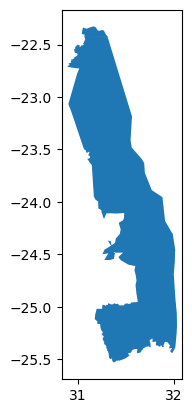

In [3]:
# import what we need for elephant profiles
import matplotlib.gridspec as gridspec
import os

!pip install geopandas -q
import geopandas as gpd

# Kruger National Park boundary shapefile
# Source: UNEP-WCMC and IUCN (2026), Protected Planet: The World Database on
# Protected Areas (WDPA) and World Database on Other Effective Area-based
# Conservation Measures (WD-OECM) [Online], July 2026, Cambridge, UK:
# UNEP-WCMC and IUCN. Available at: www.protectedplanet.net.

# Load Kruger boundary shapefile
import geopandas as gpd

kruger_boundary = gpd.read_file(f"{BASE_PATH}/boundary//WDPA_WDOECM_Jul2026_Public_873_shp-polygons.shp")

# Make sure it's in the same coordinate system as your GPS points (lat/lon, EPSG:4326)
kruger_boundary = kruger_boundary.to_crs(epsg=4326)

print(kruger_boundary.crs)
kruger_boundary.plot()  # quick sanity check that it looks like Kruger's outline

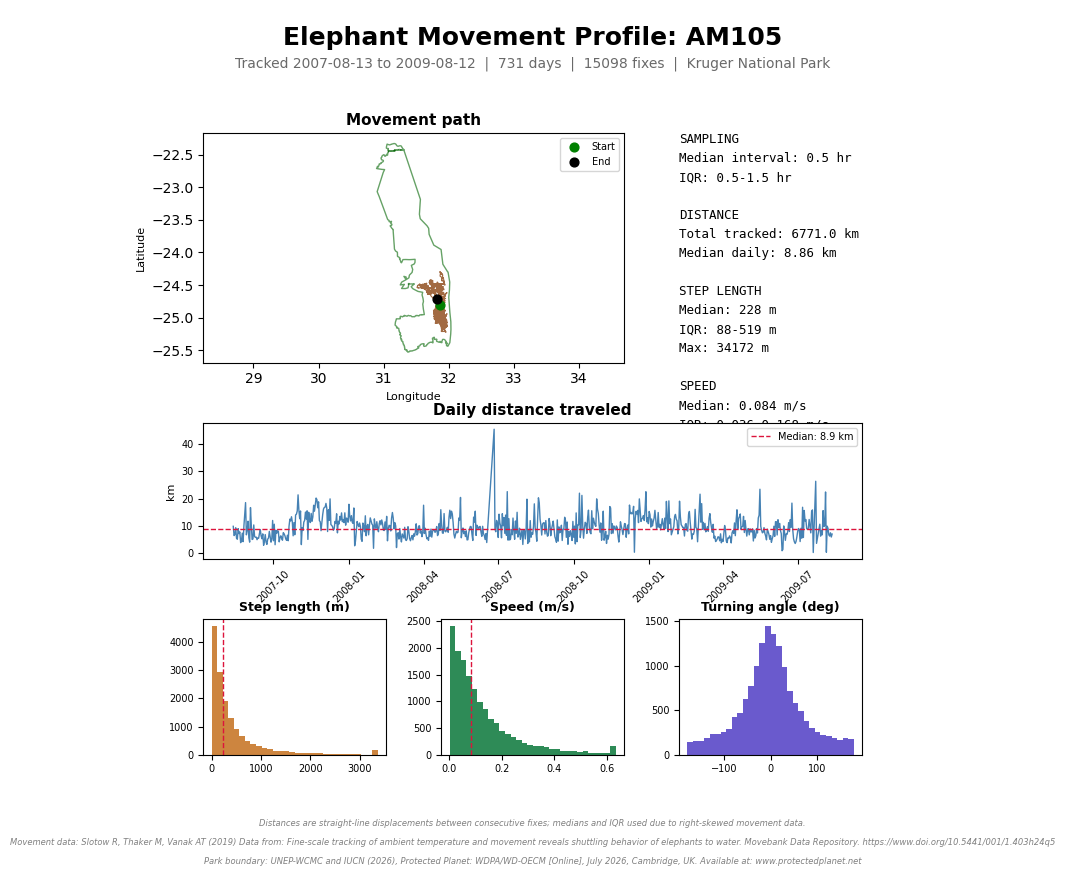

Saved: /content/drive/MyDrive/wildlife_data/projects/elephants_temperature_knp/outputs/elephant_profiles/AM105_profile.pdf


'/content/drive/MyDrive/wildlife_data/projects/elephants_temperature_knp/outputs/elephant_profiles/AM105_profile.pdf'

In [4]:
# Preview: single-elephant test run
# Confirms the profile function works correctly before generating all 14.
# Example shown below for AM105

elephant_profile_pdf(df_moves, "AM105", kruger_boundary,
                      output_dir=f"{BASE_PATH}/outputs/elephant_profiles")

In [5]:
# loop over all 14
for eid in df_moves['individual-local-identifier'].unique():
    elephant_profile_pdf(df_moves, eid, kruger_boundary,
                          output_dir=f"{BASE_PATH}/outputs/elephant_profiles",
                          preview=False)

Saved: /content/drive/MyDrive/wildlife_data/projects/elephants_temperature_knp/outputs/elephant_profiles/AM105_profile.pdf
Saved: /content/drive/MyDrive/wildlife_data/projects/elephants_temperature_knp/outputs/elephant_profiles/AM107_profile.pdf
Saved: /content/drive/MyDrive/wildlife_data/projects/elephants_temperature_knp/outputs/elephant_profiles/AM108_profile.pdf
Saved: /content/drive/MyDrive/wildlife_data/projects/elephants_temperature_knp/outputs/elephant_profiles/AM110_profile.pdf
Saved: /content/drive/MyDrive/wildlife_data/projects/elephants_temperature_knp/outputs/elephant_profiles/AM239_profile.pdf
Saved: /content/drive/MyDrive/wildlife_data/projects/elephants_temperature_knp/outputs/elephant_profiles/AM253_profile.pdf
Saved: /content/drive/MyDrive/wildlife_data/projects/elephants_temperature_knp/outputs/elephant_profiles/AM254_profile.pdf
Saved: /content/drive/MyDrive/wildlife_data/projects/elephants_temperature_knp/outputs/elephant_profiles/AM255_profile.pdf
Saved: /content/

In [6]:
os.listdir(f"{BASE_PATH}/outputs/elephant_profiles")

['AM107_profile.pdf',
 'AM108_profile.pdf',
 'AM110_profile.pdf',
 'AM239_profile.pdf',
 'AM253_profile.pdf',
 'AM254_profile.pdf',
 'AM255_profile.pdf',
 'AM306_profile.pdf',
 'AM307_profile.pdf',
 'AM308_profile.pdf',
 'AM91_profile.pdf',
 'AM93_profile.pdf',
 'AM99_profile.pdf',
 'AM105_profile.pdf']